In [ ]:
import os
import json
import math
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.datasets import Flowers102, OxfordIIITPet
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.transforms import v2, InterpolationMode

print(f"torch={torch.__version__}")
print(f"torchvision={torchvision.__version__}")

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

torch=2.11.0+cu130
torchvision=0.26.0+cu130


In [ ]:
NB_DIR = Path(".")
ARTIFACTS_DIR = NB_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"

RUNS_CSV_REL = Path("artifacts/runs.csv")
BEST_MODEL_REL = Path("artifacts/best_classifier.pt")
BEST_CONFIG_REL = Path("artifacts/best_classifier_config.json")
BEST_CURVES_REL = Path("artifacts/figures/classification_curves_best.png")
CLASS_COMPARE_REL = Path("artifacts/figures/classification_compare.png")
AUG_PREVIEW_REL = Path("artifacts/figures/augmentations_preview.png")
SEG_EXAMPLES_REL = Path("artifacts/figures/segmentation_examples.png")
SEG_METRICS_REL = Path("artifacts/figures/segmentation_metrics.png")

DATA_DIR_REL = Path("../../data")
DATA_DIR = (NB_DIR / DATA_DIR_REL).resolve()

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACT_PATHS = {
    "runs_csv": RUNS_CSV_REL,
    "best_classifier_pt": BEST_MODEL_REL,
    "best_classifier_config_json": BEST_CONFIG_REL,
    "classification_curves_best_png": BEST_CURVES_REL,
    "classification_compare_png": CLASS_COMPARE_REL,
    "augmentations_preview_png": AUG_PREVIEW_REL,
    "segmentation_examples_png": SEG_EXAMPLES_REL,
    "segmentation_metrics_png": SEG_METRICS_REL,
    "data_dir": DATA_DIR_REL,
}

print("Notebook-relative paths:")
for name, rel_path in ARTIFACT_PATHS.items():
    print(f"{name:35s} -> {rel_path}")

Notebook-relative paths:
runs_csv                            -> artifacts/runs.csv
best_classifier_pt                  -> artifacts/best_classifier.pt
best_classifier_config_json         -> artifacts/best_classifier_config.json
classification_curves_best_png      -> artifacts/figures/classification_curves_best.png
classification_compare_png          -> artifacts/figures/classification_compare.png
augmentations_preview_png           -> artifacts/figures/augmentations_preview.png
segmentation_examples_png           -> artifacts/figures/segmentation_examples.png
segmentation_metrics_png            -> artifacts/figures/segmentation_metrics.png
data_dir                            -> ../../data


In [ ]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0 if os.name == "nt" else min(4, os.cpu_count() or 2)

CONFIG = {
    "seed": SEED,
    "device": str(DEVICE),
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
    "classification": {
        "dataset_name": "Flowers102",
        "num_classes": len(Flowers102.classes),
        "cnn_image_size": 128,
        "resnet_image_size": 224,
        "batch_size_cnn": 64 if DEVICE.type == "cuda" else 32,
        "batch_size_resnet": 32 if DEVICE.type == "cuda" else 16,
        "weight_decay": 1e-4,
        "epochs": {
            "C1": 12,
            "C2": 12,
            "C3": 6,
            "C4": 8,
        },
        "lr": {
            "C1": 3e-3,
            "C2": 3e-3,
            "C3": 2e-3,
            "C4": 1e-3,
        },
    },
    "segmentation": {
        "dataset_name": "OxfordIIITPet",
        "image_size": 520,
        "batch_size": 4 if DEVICE.type == "cuda" else 2,
        "max_visualizations": 6,
        "modes": {
            "V1": {
                "threshold": 0.35,
                "use_morphology": False,
                "notes": "raw thresholding"
            },
            "V2": {
                "threshold": 0.30,
                "use_morphology": True,
                "notes": "thresholding + morphology"
            },
        },
        "kernel_small": 3,
        "kernel_large": 5,
    },
    "artifacts": {k: str(v) for k, v in ARTIFACT_PATHS.items()},
}

print(json.dumps(CONFIG, indent=2))

{
  "seed": 42,
  "device": "cuda",
  "num_workers": 4,
  "pin_memory": true,
  "persistent_workers": true,
  "classification": {
    "dataset_name": "Flowers102",
    "num_classes": 102,
    "cnn_image_size": 128,
    "resnet_image_size": 224,
    "batch_size_cnn": 64,
    "batch_size_resnet": 32,
    "weight_decay": 0.0001,
    "epochs": {
      "C1": 12,
      "C2": 12,
      "C3": 6,
      "C4": 8
    },
    "lr": {
      "C1": 0.003,
      "C2": 0.003,
      "C3": 0.002,
      "C4": 0.001
    }
  },
  "segmentation": {
    "dataset_name": "OxfordIIITPet",
    "image_size": 520,
    "batch_size": 4,
    "max_visualizations": 6,
    "modes": {
      "V1": {
        "threshold": 0.35,
        "use_morphology": false,
        "notes": "raw thresholding"
      },
      "V2": {
        "threshold": 0.3,
        "use_morphology": true,
        "notes": "thresholding + morphology"
      }
    },
    "kernel_small": 3,
    "kernel_large": 5
  },
  "artifacts": {
    "runs_csv": "artifacts/

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

RUNS_COLUMNS = [
    "experiment_id",
    "task",
    "dataset",
    "seed",
    "model_summary",
    "optimizer",
    "lr",
    "epochs_trained",
    "best_val_accuracy",
    "test_accuracy",
    "precision",
    "recall",
    "mean_iou",
    "notes",
]

def ensure_parent(path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

def save_json(path: Path, payload: dict) -> None:
    ensure_parent(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

def init_runs_csv(csv_path: Path) -> None:
    ensure_parent(csv_path)
    if not csv_path.exists():
        pd.DataFrame(columns=RUNS_COLUMNS).to_csv(csv_path, index=False)

def read_runs(csv_path: Path) -> pd.DataFrame:
    init_runs_csv(csv_path)
    return pd.read_csv(csv_path)

def upsert_run_row(csv_path: Path, row: dict, key: str = "experiment_id") -> None:
    init_runs_csv(csv_path)
    df = pd.read_csv(csv_path)
    row_df = pd.DataFrame([row])

    if key in df.columns and row[key] in set(df[key].tolist()):
        df = df[df[key] != row[key]]
    df = pd.concat([df, row_df], ignore_index=True)
    df.to_csv(csv_path, index=False)

def count_parameters(model: nn.Module, trainable_only: bool = False) -> int:
    params = model.parameters()
    if trainable_only:
        params = [p for p in params if p.requires_grad]
    return sum(p.numel() for p in params)

def denormalize_image(x: torch.Tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD) -> torch.Tensor:
    if x.ndim != 3:
        raise ValueError(f"Expected CHW tensor, got shape={tuple(x.shape)}")
    mean_t = torch.tensor(mean, dtype=x.dtype, device=x.device).view(3, 1, 1)
    std_t = torch.tensor(std, dtype=x.dtype, device=x.device).view(3, 1, 1)
    return x * std_t + mean_t

def tensor_to_display_image(x: torch.Tensor, denorm: bool = True) -> np.ndarray:
    x = x.detach().cpu()
    if denorm:
        x = denormalize_image(x)
    x = x.clamp(0, 1)
    return x.permute(1, 2, 0).numpy()

def save_fig(fig: plt.Figure, rel_path: Path, dpi: int = 150) -> None:
    abs_path = (NB_DIR / rel_path).resolve()
    ensure_parent(abs_path)
    fig.savefig(abs_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {rel_path}")

def plot_image_grid(
    images,
    titles=None,
    cols: int = 4,
    figsize=(12, 8),
    denorm: bool = True,
):
    n = len(images)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(rows, cols)

    for ax in axes.ravel():
        ax.axis("off")

    for i, img in enumerate(images):
        ax = axes.ravel()[i]
        if isinstance(img, torch.Tensor):
            if img.ndim == 3 and img.shape[0] == 3:
                ax.imshow(tensor_to_display_image(img, denorm=denorm))
            elif img.ndim == 2:
                ax.imshow(img.detach().cpu().numpy(), cmap="gray")
            else:
                raise ValueError(f"Unsupported tensor image shape: {tuple(img.shape)}")
        elif isinstance(img, np.ndarray):
            if img.ndim == 2:
                ax.imshow(img, cmap="gray")
            else:
                ax.imshow(img)
        else:
            ax.imshow(img)

        if titles is not None:
            ax.set_title(str(titles[i]), fontsize=10)

    fig.tight_layout()
    return fig

def plot_classification_curves(history: dict, title: str = "") -> plt.Figure:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="train_loss")
    axes[0].plot(history["val_loss"], label="val_loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="train_acc")
    axes[1].plot(history["val_acc"], label="val_acc")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    if title:
        fig.suptitle(title)
    fig.tight_layout()
    return fig

In [ ]:
def get_classification_transforms(model_family: str, with_aug: bool = False):
    if model_family == "simple_cnn":
        size = CONFIG["classification"]["cnn_image_size"]

        train_ops = []
        if with_aug:
            train_ops.extend([
                v2.RandomResizedCrop(size=(size, size), scale=(0.75, 1.0), antialias=True),
                v2.RandomHorizontalFlip(p=0.5),
                v2.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
            ])
        else:
            train_ops.append(v2.Resize((size, size), antialias=True))

        train_transform = v2.Compose([
            *train_ops,
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

        eval_transform = v2.Compose([
            v2.Resize((size, size), antialias=True),
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
        return train_transform, eval_transform

    if model_family == "resnet18":
        size = CONFIG["classification"]["resnet_image_size"]

        train_transform = v2.Compose([
            v2.RandomResizedCrop(size=(size, size), scale=(0.7, 1.0), antialias=True),
            v2.RandomHorizontalFlip(p=0.5),
            v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

        eval_transform = v2.Compose([
            v2.Resize(256, antialias=True),
            v2.CenterCrop(size),
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
        return train_transform, eval_transform

    raise ValueError(f"Unknown model_family={model_family}")

def get_segmentation_image_transform():
    size = CONFIG["segmentation"]["image_size"]
    return v2.Compose([
        v2.Resize((size, size), interpolation=InterpolationMode.BILINEAR, antialias=True),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

In [ ]:
FLOWER_CLASSES = Flowers102.classes
_CLASSIFICATION_DATASET_CACHE = {}

def build_flowers_datasets(model_family: str, with_aug: bool, download: bool = True):
    cache_key = (model_family, with_aug)
    if cache_key in _CLASSIFICATION_DATASET_CACHE:
        return _CLASSIFICATION_DATASET_CACHE[cache_key]

    train_transform, eval_transform = get_classification_transforms(
        model_family=model_family,
        with_aug=with_aug,
    )

    datasets = {
        "train": Flowers102(
            root=DATA_DIR,
            split="train",
            download=download,
            transform=train_transform,
        ),
        "val": Flowers102(
            root=DATA_DIR,
            split="val",
            download=download,
            transform=eval_transform,
        ),
        "test": Flowers102(
            root=DATA_DIR,
            split="test",
            download=download,
            transform=eval_transform,
        ),
    }
    _CLASSIFICATION_DATASET_CACHE[cache_key] = datasets
    return datasets

def build_classification_loaders(model_family: str, with_aug: bool, download: bool = True):
    datasets = build_flowers_datasets(model_family=model_family, with_aug=with_aug, download=download)

    if model_family == "simple_cnn":
        batch_size = CONFIG["classification"]["batch_size_cnn"]
    elif model_family == "resnet18":
        batch_size = CONFIG["classification"]["batch_size_resnet"]
    else:
        raise ValueError(f"Unknown model_family={model_family}")

    loaders = {
        split: DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=(split == "train"),
            num_workers=CONFIG["num_workers"],
            pin_memory=CONFIG["pin_memory"],
            persistent_workers=CONFIG["persistent_workers"],
        )
        for split, ds in datasets.items()
    }
    return datasets, loaders

Flowers102 sizes:
train: 1020
  val: 1020
 test: 6149
x.shape = (64, 3, 128, 128)
y.shape = (64,)
x.dtype = torch.float32
y.dtype = torch.int64


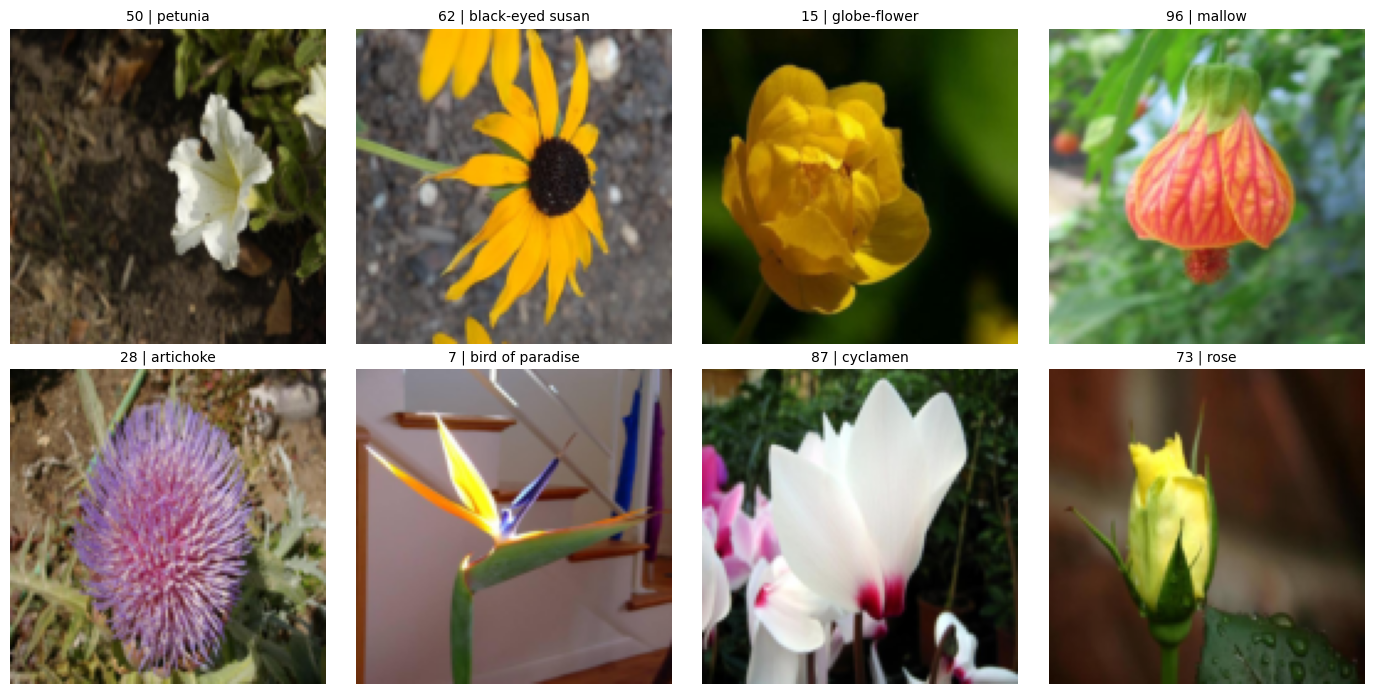

In [ ]:
datasets_preview, loaders_preview = build_classification_loaders(
    model_family="simple_cnn",
    with_aug=False,
    download=True,
)

print("Flowers102 sizes:")
for split, ds in datasets_preview.items():
    print(f"{split:>5s}: {len(ds)}")

xb, yb = next(iter(loaders_preview["train"]))
print(f"x.shape = {tuple(xb.shape)}")
print(f"y.shape = {tuple(yb.shape)}")
print(f"x.dtype = {xb.dtype}")
print(f"y.dtype = {yb.dtype}")

n_show = min(8, xb.size(0))
images = [xb[i].cpu() for i in range(n_show)]
titles = [f"{yb[i].item()} | {FLOWER_CLASSES[yb[i].item()]}" for i in range(n_show)]
fig = plot_image_grid(images, titles=titles, cols=4, figsize=(14, 7), denorm=True)
plt.show()

Flowers102 sizes:
train: 1020
  val: 1020
 test: 6149
x.shape = (64, 3, 128, 128)
y.shape = (64,)
x.dtype = torch.float32
y.dtype = torch.int64


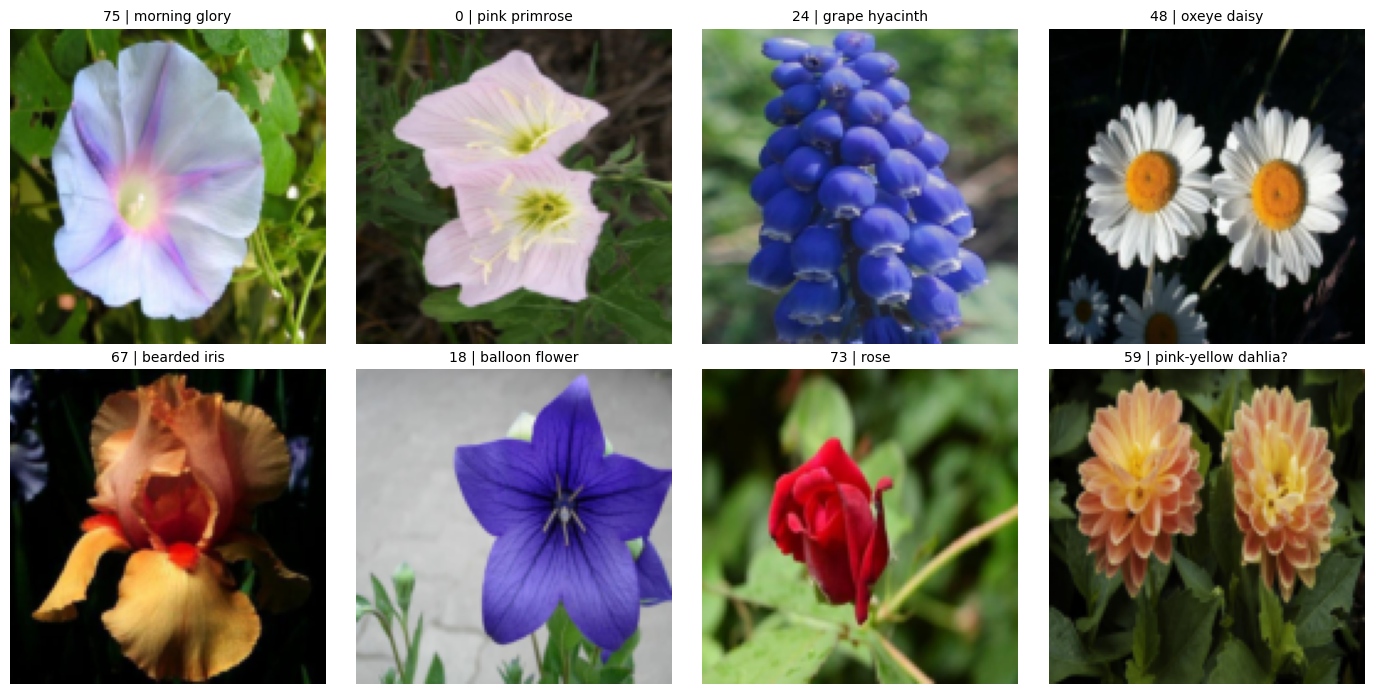

In [ ]:
datasets_preview, loaders_preview = build_classification_loaders(
    model_family="simple_cnn",
    with_aug=False,
    download=True,
)

print("Flowers102 sizes:")
for split, ds in datasets_preview.items():
    print(f"{split:>5s}: {len(ds)}")

xb, yb = next(iter(loaders_preview["train"]))
print(f"x.shape = {tuple(xb.shape)}")
print(f"y.shape = {tuple(yb.shape)}")
print(f"x.dtype = {xb.dtype}")
print(f"y.dtype = {yb.dtype}")

n_show = min(8, xb.size(0))
images = [xb[i].cpu() for i in range(n_show)]
titles = [f"{yb[i].item()} | {FLOWER_CLASSES[yb[i].item()]}" for i in range(n_show)]
fig = plot_image_grid(images, titles=titles, cols=4, figsize=(14, 7), denorm=True)
plt.show()

Saved: artifacts/figures/augmentations_preview.png


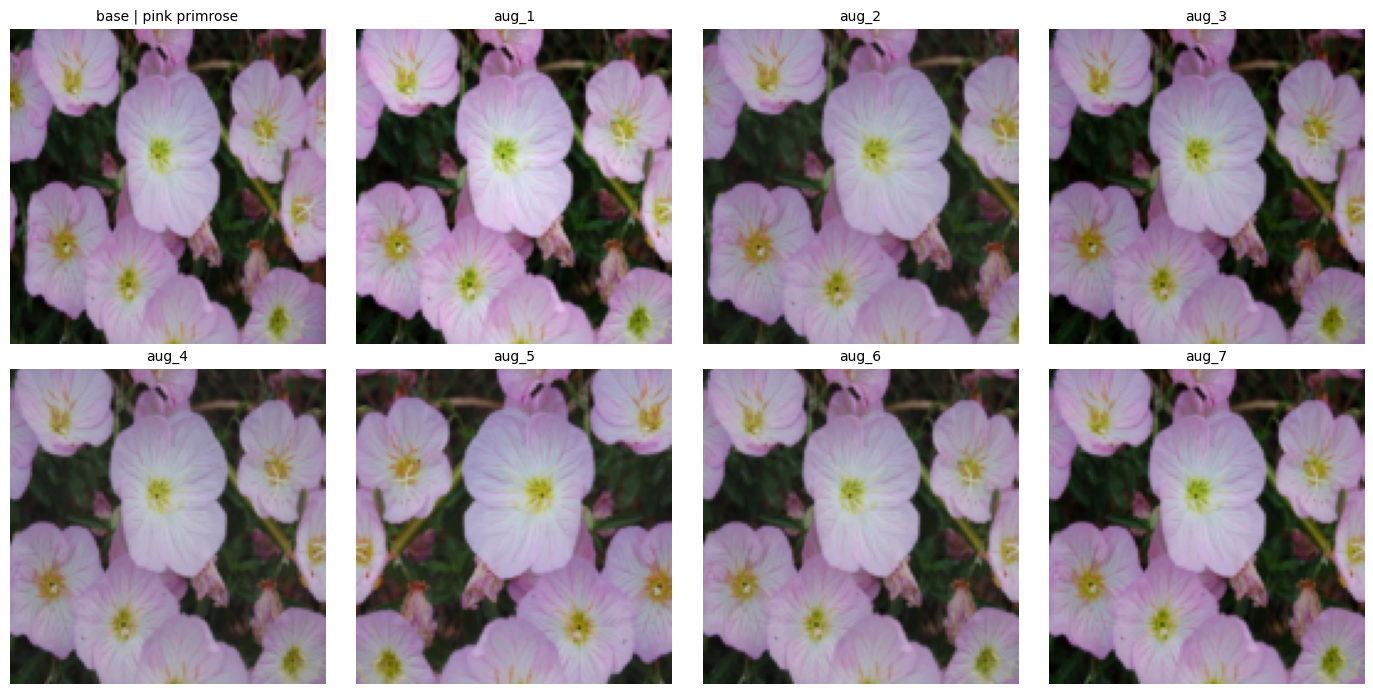

In [ ]:
raw_flowers_train = Flowers102(root=DATA_DIR, split="train", download=True)
raw_img, raw_label = raw_flowers_train[0]

base_train_transform, _ = get_classification_transforms(model_family="simple_cnn", with_aug=False)
aug_train_transform, _ = get_classification_transforms(model_family="simple_cnn", with_aug=True)

preview_images = [base_train_transform(raw_img)]
preview_titles = [f"base | {FLOWER_CLASSES[raw_label]}"]

for i in range(7):
    preview_images.append(aug_train_transform(raw_img))
    preview_titles.append(f"aug_{i+1}")

fig = plot_image_grid(
    preview_images,
    titles=preview_titles,
    cols=4,
    figsize=(14, 7),
    denorm=True,
)
save_fig(fig, AUG_PREVIEW_REL)
plt.show()

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, p_drop: float = 0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        ]
        if p_drop > 0:
            layers.append(nn.Dropout2d(p_drop))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32, p_drop=0.05),
            ConvBlock(32, 64, p_drop=0.10),
            ConvBlock(64, 128, p_drop=0.15),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.30),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x

def build_resnet18_classifier(num_classes: int, freeze_mode: str = "head_only") -> nn.Module:
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    if freeze_mode == "head_only":
        for p in model.parameters():
            p.requires_grad = False
        for p in model.fc.parameters():
            p.requires_grad = True

    elif freeze_mode == "layer4_fc":
        for p in model.parameters():
            p.requires_grad = False
        for p in model.layer4.parameters():
            p.requires_grad = True
        for p in model.fc.parameters():
            p.requires_grad = True

    elif freeze_mode == "full":
        for p in model.parameters():
            p.requires_grad = True

    else:
        raise ValueError(f"Unknown freeze_mode={freeze_mode}")

    return model

def build_classifier(exp_cfg: dict) -> nn.Module:
    num_classes = CONFIG["classification"]["num_classes"]

    if exp_cfg["model_family"] == "simple_cnn":
        model = SimpleCNN(num_classes=num_classes)
    elif exp_cfg["model_family"] == "resnet18":
        model = build_resnet18_classifier(
            num_classes=num_classes,
            freeze_mode=exp_cfg["freeze_mode"],
        )
    else:
        raise ValueError(f"Unknown model_family={exp_cfg['model_family']}")

    return model.to(DEVICE)

In [ ]:
def freeze_batchnorm_stats(module: nn.Module) -> None:
    for m in module.modules():
        if isinstance(m, nn.modules.batchnorm._BatchNorm):
            m.eval()

def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

def build_optimizer(model: nn.Module, exp_cfg: dict):
    weight_decay = CONFIG["classification"]["weight_decay"]

    if exp_cfg["model_family"] == "simple_cnn":
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=exp_cfg["lr"],
            weight_decay=weight_decay,
        )
        optimizer_name = "AdamW"
        return optimizer, optimizer_name

    if exp_cfg["experiment_id"] == "C4":
        optimizer = torch.optim.AdamW(
            [
                {"params": [p for p in model.layer4.parameters() if p.requires_grad], "lr": exp_cfg["lr"] * 0.3},
                {"params": [p for p in model.fc.parameters() if p.requires_grad], "lr": exp_cfg["lr"]},
            ],
            weight_decay=weight_decay,
        )
        optimizer_name = "AdamW(param_groups: layer4 lower LR, fc base LR)"
    else:
        optimizer = torch.optim.AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=exp_cfg["lr"],
            weight_decay=weight_decay,
        )
        optimizer_name = "AdamW"

    return optimizer, optimizer_name

def build_scheduler(optimizer, exp_cfg: dict):
    return torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=exp_cfg["epochs"],
    )

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer,
    criterion,
    device: torch.device,
    freeze_bn: bool = False,
):
    model.train()
    if freeze_bn:
        freeze_batchnorm_stats(model)

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        batch_size = xb.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (logits.argmax(dim=1) == yb).sum().item()
        running_total += batch_size

    return {
        "loss": running_loss / running_total,
        "accuracy": running_correct / running_total,
    }

@torch.inference_mode()
def evaluate_classifier(
    model: nn.Module,
    loader: DataLoader,
    criterion,
    device: torch.device,
):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        batch_size = xb.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (logits.argmax(dim=1) == yb).sum().item()
        running_total += batch_size

    return {
        "loss": running_loss / running_total,
        "accuracy": running_correct / running_total,
    }

def fit_classifier(
    model: nn.Module,
    loaders: dict,
    exp_cfg: dict,
    device: torch.device,
):
    criterion = nn.CrossEntropyLoss()
    optimizer, optimizer_name = build_optimizer(model, exp_cfg)
    scheduler = build_scheduler(optimizer, exp_cfg)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
    }

    best_val_acc = -1.0
    best_epoch = -1
    best_state_dict = None

    for epoch in range(1, exp_cfg["epochs"] + 1):
        train_metrics = train_one_epoch(
            model=model,
            loader=loaders["train"],
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            freeze_bn=(exp_cfg.get("freeze_mode") == "head_only"),
        )
        val_metrics = evaluate_classifier(
            model=model,
            loader=loaders["val"],
            criterion=criterion,
            device=device,
        )

        scheduler.step()

        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_epoch = epoch
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(
            f"[{exp_cfg['experiment_id']}] "
            f"epoch {epoch:02d}/{exp_cfg['epochs']:02d} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"train_acc={train_metrics['accuracy']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f}"
        )

    result = {
        "exp_cfg": copy.deepcopy(exp_cfg),
        "optimizer_name": optimizer_name,
        "history": history,
        "best_val_accuracy": float(best_val_acc),
        "best_epoch": int(best_epoch),
        "best_state_dict": best_state_dict,
        "trainable_params": int(count_parameters(model, trainable_only=True)),
        "total_params": int(count_parameters(model, trainable_only=False)),
    }
    return result

In [ ]:
CLASSIFICATION_EXPERIMENTS = [
    {
        "experiment_id": "C1",
        "task": "classification",
        "dataset": "Flowers102",
        "model_family": "simple_cnn",
        "freeze_mode": None,
        "with_aug": False,
        "epochs": CONFIG["classification"]["epochs"]["C1"],
        "lr": CONFIG["classification"]["lr"]["C1"],
        "notes": "simple-cnn-base",
    },
    {
        "experiment_id": "C2",
        "task": "classification",
        "dataset": "Flowers102",
        "model_family": "simple_cnn",
        "freeze_mode": None,
        "with_aug": True,
        "epochs": CONFIG["classification"]["epochs"]["C2"],
        "lr": CONFIG["classification"]["lr"]["C2"],
        "notes": "simple-cnn-aug",
    },
    {
        "experiment_id": "C3",
        "task": "classification",
        "dataset": "Flowers102",
        "model_family": "resnet18",
        "freeze_mode": "head_only",
        "with_aug": True,
        "epochs": CONFIG["classification"]["epochs"]["C3"],
        "lr": CONFIG["classification"]["lr"]["C3"],
        "notes": "resnet18-head-only",
    },
    {
        "experiment_id": "C4",
        "task": "classification",
        "dataset": "Flowers102",
        "model_family": "resnet18",
        "freeze_mode": "layer4_fc",
        "with_aug": True,
        "epochs": CONFIG["classification"]["epochs"]["C4"],
        "lr": CONFIG["classification"]["lr"]["C4"],
        "notes": "resnet18-finetune-layer4+fc",
    },
]

init_runs_csv(NB_DIR / RUNS_CSV_REL)
pd.DataFrame(columns=RUNS_COLUMNS).to_csv(NB_DIR / RUNS_CSV_REL, index=False)

print("Runs CSV reset:")
display(read_runs(NB_DIR / RUNS_CSV_REL))

Runs CSV reset:


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes


In [ ]:
classification_results = {}

for exp_cfg in CLASSIFICATION_EXPERIMENTS:
    print("=" * 100)
    print(f"Starting {exp_cfg['experiment_id']} | {exp_cfg['notes']}")

    _, loaders = build_classification_loaders(
        model_family=exp_cfg["model_family"],
        with_aug=exp_cfg["with_aug"],
        download=True,
    )

    model = build_classifier(exp_cfg)
    result = fit_classifier(
        model=model,
        loaders=loaders,
        exp_cfg=exp_cfg,
        device=DEVICE,
    )

    model_summary = (
        f"{exp_cfg['model_family']}"
        f"(trainable={result['trainable_params']}, total={result['total_params']}, "
        f"freeze_mode={exp_cfg['freeze_mode']})"
    )

    row = {
        "experiment_id": exp_cfg["experiment_id"],
        "task": exp_cfg["task"],
        "dataset": exp_cfg["dataset"],
        "seed": CONFIG["seed"],
        "model_summary": model_summary,
        "optimizer": result["optimizer_name"],
        "lr": exp_cfg["lr"],
        "epochs_trained": exp_cfg["epochs"],
        "best_val_accuracy": result["best_val_accuracy"],
        "test_accuracy": np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "mean_iou": np.nan,
        "notes": exp_cfg["notes"],
    }

    upsert_run_row(NB_DIR / RUNS_CSV_REL, row)
    classification_results[exp_cfg["experiment_id"]] = result

classification_runs_df = read_runs(NB_DIR / RUNS_CSV_REL)
classification_runs_df = classification_runs_df[classification_runs_df["task"] == "classification"].copy()
classification_runs_df = classification_runs_df.sort_values("experiment_id").reset_index(drop=True)
display(classification_runs_df)

Starting C1 | simple-cnn-base
[C1] epoch 01/12 | train_loss=4.5977 | train_acc=0.0108 | val_loss=4.7886 | val_acc=0.0382
[C1] epoch 02/12 | train_loss=4.2570 | train_acc=0.0294 | val_loss=4.2546 | val_acc=0.0520
[C1] epoch 03/12 | train_loss=4.0074 | train_acc=0.0480 | val_loss=3.8765 | val_acc=0.0745
[C1] epoch 04/12 | train_loss=3.8506 | train_acc=0.0637 | val_loss=3.8925 | val_acc=0.0755
[C1] epoch 05/12 | train_loss=3.7387 | train_acc=0.0794 | val_loss=3.7156 | val_acc=0.0971
[C1] epoch 06/12 | train_loss=3.6273 | train_acc=0.0794 | val_loss=3.5806 | val_acc=0.1176
[C1] epoch 07/12 | train_loss=3.4647 | train_acc=0.1196 | val_loss=3.5511 | val_acc=0.1382
[C1] epoch 08/12 | train_loss=3.4151 | train_acc=0.1167 | val_loss=3.4636 | val_acc=0.1510
[C1] epoch 09/12 | train_loss=3.3438 | train_acc=0.1441 | val_loss=3.4395 | val_acc=0.1539
[C1] epoch 10/12 | train_loss=3.3505 | train_acc=0.1402 | val_loss=3.4268 | val_acc=0.1559
[C1] epoch 11/12 | train_loss=3.2590 | train_acc=0.1618 | va

/tmp/ipykernel_39706/2755512311.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, row_df], ignore_index=True)


[C2] epoch 01/12 | train_loss=4.6154 | train_acc=0.0127 | val_loss=4.5111 | val_acc=0.0245
[C2] epoch 02/12 | train_loss=4.2712 | train_acc=0.0324 | val_loss=3.9963 | val_acc=0.0510
[C2] epoch 03/12 | train_loss=3.9683 | train_acc=0.0627 | val_loss=3.8177 | val_acc=0.1020
[C2] epoch 04/12 | train_loss=3.7282 | train_acc=0.0882 | val_loss=3.6570 | val_acc=0.1039
[C2] epoch 05/12 | train_loss=3.6064 | train_acc=0.0971 | val_loss=3.5717 | val_acc=0.1225
[C2] epoch 06/12 | train_loss=3.4677 | train_acc=0.1059 | val_loss=3.5248 | val_acc=0.1255
[C2] epoch 07/12 | train_loss=3.4266 | train_acc=0.1245 | val_loss=3.5002 | val_acc=0.1343
[C2] epoch 08/12 | train_loss=3.3559 | train_acc=0.1098 | val_loss=3.4679 | val_acc=0.1529
[C2] epoch 09/12 | train_loss=3.2836 | train_acc=0.1402 | val_loss=3.4202 | val_acc=0.1608
[C2] epoch 10/12 | train_loss=3.2645 | train_acc=0.1539 | val_loss=3.3963 | val_acc=0.1627
[C2] epoch 11/12 | train_loss=3.2218 | train_acc=0.1490 | val_loss=3.3879 | val_acc=0.1706

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,Flowers102,42,"simple_cnn(trainable=346694, total=346694, fre...",AdamW,0.003,12,0.161765,NaN,NaN,NaN,NaN,simple-cnn-base
1,C2,classification,Flowers102,42,"simple_cnn(trainable=346694, total=346694, fre...",AdamW,0.003,12,0.171569,NaN,NaN,NaN,NaN,simple-cnn-aug
2,C3,classification,Flowers102,42,"resnet18(trainable=52326, total=11228838, free...",AdamW,0.002,6,0.788235,NaN,NaN,NaN,NaN,resnet18-head-only
3,C4,classification,Flowers102,42,"resnet18(trainable=8446054, total=11228838, fr...","AdamW(param_groups: layer4 lower LR, fc base LR)",0.001,8,0.911765,NaN,NaN,NaN,NaN,resnet18-finetune-layer4+fc


Best classification experiment: C4


,experiment_id,best_val_accuracy,best_epoch,trainable_params,total_params,notes
0,C4,0.911765,8,8446054,11228838,resnet18-finetune-layer4+fc
1,C3,0.788235,5,52326,11228838,resnet18-head-only
2,C2,0.171569,12,346694,346694,simple-cnn-aug
3,C1,0.161765,11,346694,346694,simple-cnn-base


Saved: artifacts/figures/classification_compare.png


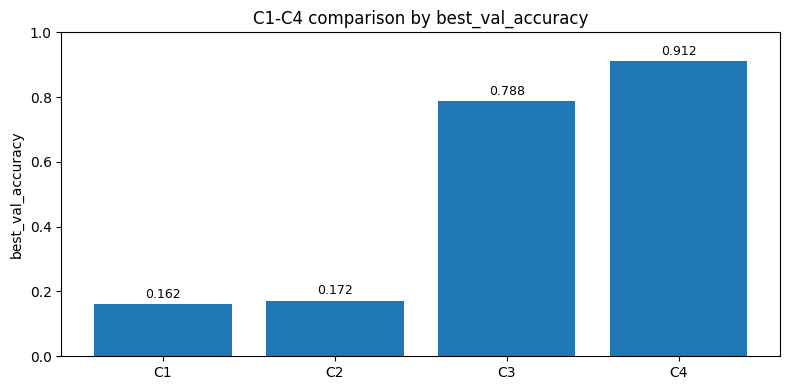

Saved: artifacts/figures/classification_curves_best.png


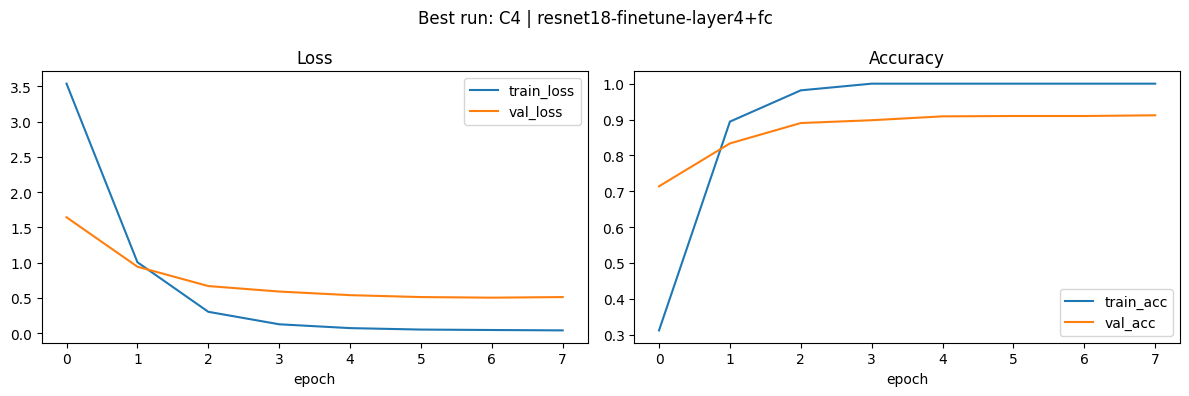

In [ ]:
classification_summary = []
for exp_id, result in classification_results.items():
    classification_summary.append({
        "experiment_id": exp_id,
        "best_val_accuracy": result["best_val_accuracy"],
        "best_epoch": result["best_epoch"],
        "trainable_params": result["trainable_params"],
        "total_params": result["total_params"],
        "notes": result["exp_cfg"]["notes"],
    })

classification_summary_df = pd.DataFrame(classification_summary).sort_values(
    "best_val_accuracy",
    ascending=False,
).reset_index(drop=True)

best_exp_id = classification_summary_df.iloc[0]["experiment_id"]
best_result = classification_results[best_exp_id]
best_cfg = best_result["exp_cfg"]

print(f"Best classification experiment: {best_exp_id}")
display(classification_summary_df)

# compare plot
plot_df = classification_summary_df.sort_values("experiment_id").copy()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(plot_df["experiment_id"], plot_df["best_val_accuracy"])
ax.set_title("C1-C4 comparison by best_val_accuracy")
ax.set_ylabel("best_val_accuracy")
ax.set_ylim(0, min(1.0, plot_df["best_val_accuracy"].max() + 0.1))

for bar, value in zip(bars, plot_df["best_val_accuracy"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

fig.tight_layout()
save_fig(fig, CLASS_COMPARE_REL)
plt.show()

# best curves plot
fig = plot_classification_curves(
    best_result["history"],
    title=f"Best run: {best_exp_id} | {best_cfg['notes']}",
)
save_fig(fig, BEST_CURVES_REL)
plt.show()

In [ ]:
print(f"Evaluating best model on test split exactly once: {best_exp_id}")

_, best_loaders = build_classification_loaders(
    model_family=best_cfg["model_family"],
    with_aug=best_cfg["with_aug"],
    download=True,
)

best_model = build_classifier(best_cfg)
best_model.load_state_dict(best_result["best_state_dict"])
best_model = best_model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
test_metrics = evaluate_classifier(
    model=best_model,
    loader=best_loaders["test"],
    criterion=criterion,
    device=DEVICE,
)

torch.save(best_result["best_state_dict"], NB_DIR / BEST_MODEL_REL)

best_config_payload = {
    "seed": CONFIG["seed"],
    "dataset": best_cfg["dataset"],
    "split_policy": {
        "train": "official Flowers102 train split",
        "val": "official Flowers102 val split",
        "test": "official Flowers102 test split",
    },
    "experiment_id": best_cfg["experiment_id"],
    "notes": best_cfg["notes"],
    "model": {
        "family": best_cfg["model_family"],
        "architecture": "resnet18",
        "pretrained": True,
        "pretrained_weights": "ResNet18_Weights.DEFAULT",
        "freeze_mode": best_cfg["freeze_mode"],
        "num_classes": CONFIG["classification"]["num_classes"],
        "image_size": (
            CONFIG["classification"]["cnn_image_size"]
            if best_cfg["model_family"] == "simple_cnn"
            else CONFIG["classification"]["resnet_image_size"]
        ),
    },
    "training": {
        "epochs": best_cfg["epochs"],
        "learning_rate": best_cfg["lr"],
        "optimizer": best_result["optimizer_name"],
        "loss": "CrossEntropyLoss",
        "weight_decay": CONFIG["classification"]["weight_decay"],
        "batch_size": (
            CONFIG["classification"]["batch_size_cnn"]
            if best_cfg["model_family"] == "simple_cnn"
            else CONFIG["classification"]["batch_size_resnet"]
        ),
        "with_aug": best_cfg["with_aug"],
    },
    "transforms": {
        "train": {
            "pipeline_name": "resnet18_train_transform",
            "steps": [
                {
                    "name": "RandomResizedCrop",
                    "params": {
                        "size": [224, 224],
                        "scale": [0.7, 1.0],
                        "antialias": True,
                    },
                },
                {
                    "name": "RandomHorizontalFlip",
                    "params": {
                        "p": 0.5,
                    },
                },
                {
                    "name": "ColorJitter",
                    "params": {
                        "brightness": 0.1,
                        "contrast": 0.1,
                        "saturation": 0.1,
                        "hue": 0.02,
                    },
                },
                {
                    "name": "ToImage",
                    "params": {},
                },
                {
                    "name": "ToDtype",
                    "params": {
                        "dtype": "torch.float32",
                        "scale": True,
                    },
                },
                {
                    "name": "Normalize",
                    "params": {
                        "mean": IMAGENET_MEAN,
                        "std": IMAGENET_STD,
                    },
                },
            ],
        },
        "eval": {
            "pipeline_name": "resnet18_eval_transform",
            "steps": [
                {
                    "name": "Resize",
                    "params": {
                        "size": 256,
                        "antialias": True,
                    },
                },
                {
                    "name": "CenterCrop",
                    "params": {
                        "size": 224,
                    },
                },
                {
                    "name": "ToImage",
                    "params": {},
                },
                {
                    "name": "ToDtype",
                    "params": {
                        "dtype": "torch.float32",
                        "scale": True,
                    },
                },
                {
                    "name": "Normalize",
                    "params": {
                        "mean": IMAGENET_MEAN,
                        "std": IMAGENET_STD,
                    },
                },
            ],
        },
    },
    "augmentation": {
        "enabled": bool(best_cfg["with_aug"]),
        "applied_in_train_only": True,
        "ops": [
            "RandomResizedCrop(size=(224,224), scale=(0.7,1.0), antialias=True)",
            "RandomHorizontalFlip(p=0.5)",
            "ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02)",
        ] if best_cfg["with_aug"] else [],
    },
    "preprocess": {
        "inference_preprocess_name": "ImageNet-style ResNet18 eval preprocess",
        "resize": 256,
        "center_crop": 224,
        "to_dtype": "torch.float32",
        "scale_to_0_1": True,
        "normalize_mean": IMAGENET_MEAN,
        "normalize_std": IMAGENET_STD,
    },
    "results": {
        "best_val_accuracy": best_result["best_val_accuracy"],
        "best_epoch": best_result["best_epoch"],
        "test_accuracy": float(test_metrics["accuracy"]),
    },
    "artifact_paths": {k: str(v) for k, v in ARTIFACT_PATHS.items()},
}
save_json(NB_DIR / BEST_CONFIG_REL, best_config_payload)

best_run_row = {
    "experiment_id": best_cfg["experiment_id"],
    "task": "classification",
    "dataset": best_cfg["dataset"],
    "seed": CONFIG["seed"],
    "model_summary": (
        f"{best_cfg['model_family']}"
        f"(trainable={best_result['trainable_params']}, total={best_result['total_params']}, "
        f"freeze_mode={best_cfg['freeze_mode']})"
    ),
    "optimizer": best_result["optimizer_name"],
    "lr": best_cfg["lr"],
    "epochs_trained": best_cfg["epochs"],
    "best_val_accuracy": best_result["best_val_accuracy"],
    "test_accuracy": float(test_metrics["accuracy"]),
    "precision": np.nan,
    "recall": np.nan,
    "mean_iou": np.nan,
    "notes": best_cfg["notes"],
}
upsert_run_row(NB_DIR / RUNS_CSV_REL, best_run_row)

print(f"best_val_accuracy = {best_result['best_val_accuracy']:.4f}")
print(f"test_accuracy     = {test_metrics['accuracy']:.4f}")
print()
print("Saved classification artifacts:")
print(f"- {BEST_MODEL_REL}")
print(f"- {BEST_CONFIG_REL}")
print(f"- {BEST_CURVES_REL}")
print(f"- {CLASS_COMPARE_REL}")
print(f"- {AUG_PREVIEW_REL}")

Evaluating best model on test split exactly once: C4
best_val_accuracy = 0.9118
test_accuracy     = 0.8889

Saved classification artifacts:
- artifacts/best_classifier.pt
- artifacts/best_classifier_config.json
- artifacts/figures/classification_curves_best.png
- artifacts/figures/classification_compare.png
- artifacts/figures/augmentations_preview.png


In [ ]:
required_classification_artifacts = [
    RUNS_CSV_REL,
    BEST_MODEL_REL,
    BEST_CONFIG_REL,
    BEST_CURVES_REL,
    CLASS_COMPARE_REL,
    AUG_PREVIEW_REL,
]

print("Classification artifact check:")
for rel_path in required_classification_artifacts:
    exists = (NB_DIR / rel_path).exists()
    print(f"[{'OK' if exists else 'MISS'}] {rel_path}")

display(read_runs(NB_DIR / RUNS_CSV_REL))

Classification artifact check:
[OK] artifacts/runs.csv
[OK] artifacts/best_classifier.pt
[OK] artifacts/best_classifier_config.json
[OK] artifacts/figures/classification_curves_best.png
[OK] artifacts/figures/classification_compare.png
[OK] artifacts/figures/augmentations_preview.png


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,Flowers102,42,"simple_cnn(trainable=346694, total=346694, fre...",AdamW,0.003,12,0.161765,NaN,NaN,NaN,NaN,simple-cnn-base
1,C2,classification,Flowers102,42,"simple_cnn(trainable=346694, total=346694, fre...",AdamW,0.003,12,0.171569,NaN,NaN,NaN,NaN,simple-cnn-aug
2,C3,classification,Flowers102,42,"resnet18(trainable=52326, total=11228838, free...",AdamW,0.002,6,0.788235,NaN,NaN,NaN,NaN,resnet18-head-only
3,C4,classification,Flowers102,42,"resnet18(trainable=8446054, total=11228838, fr...","AdamW(param_groups: layer4 lower LR, fc base LR)",0.001,8,0.911765,0.888925,NaN,NaN,NaN,resnet18-finetune-layer4+fc


OxfordIIITPet trainval size: 3680
OxfordIIITPet test size:     3669


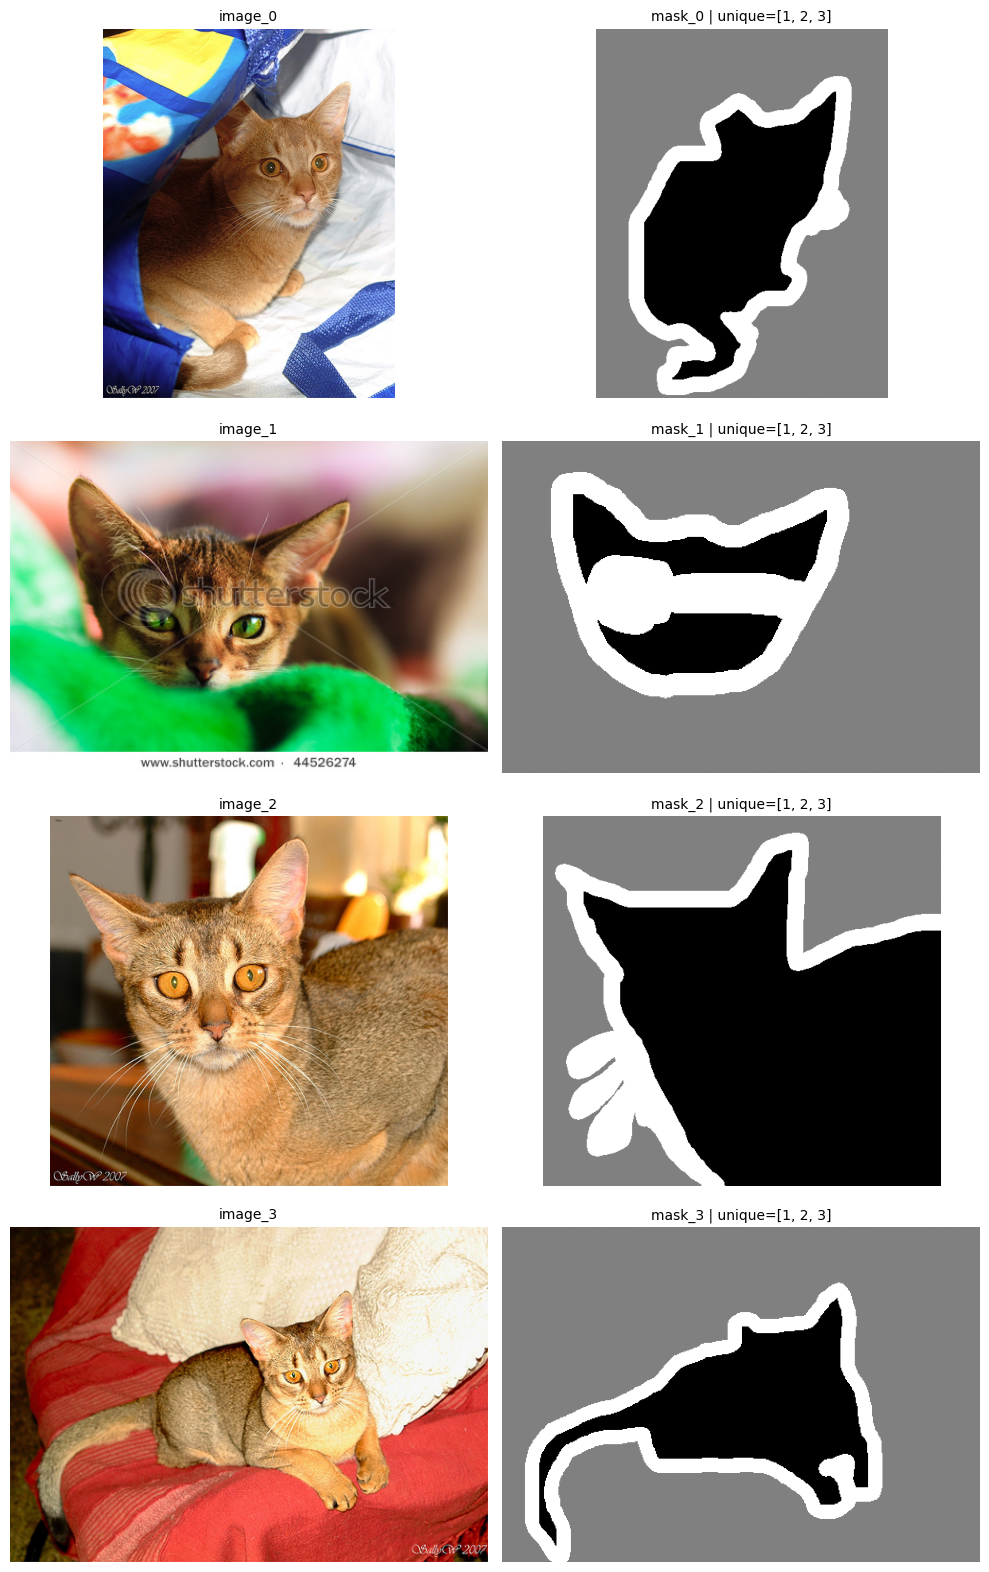

seg_x.shape = (4, 3, 520, 520)
seg_m.shape = (4, 520, 520)
seg mask unique values in batch[0]: [1, 2, 3]


In [ ]:
raw_pet_trainval = OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="segmentation",
    download=True,
)
raw_pet_test = OxfordIIITPet(
    root=DATA_DIR,
    split="test",
    target_types="segmentation",
    download=True,
)

print(f"OxfordIIITPet trainval size: {len(raw_pet_trainval)}")
print(f"OxfordIIITPet test size:     {len(raw_pet_test)}")

seg_preview_images = []
seg_preview_titles = []

for idx in range(4):
    img, mask = raw_pet_trainval[idx]
    seg_preview_images.extend([np.array(img), np.array(mask)])
    seg_preview_titles.extend([
        f"image_{idx}",
        f"mask_{idx} | unique={np.unique(np.array(mask)).tolist()}",
    ])

fig = plot_image_grid(
    seg_preview_images,
    titles=seg_preview_titles,
    cols=2,
    figsize=(10, 16),
    denorm=False,
)
plt.show()

class OxfordPetSegmentationEvalDataset(Dataset):
    def __init__(self, root: Path, split: str, download: bool = True):
        self.base = OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=download,
        )
        self.image_transform = get_segmentation_image_transform()

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image_pil, mask_pil = self.base[idx]
        image_pil = image_pil.convert("RGB")

        image_tensor = self.image_transform(image_pil)
        _, h, w = image_tensor.shape

        mask_resized = mask_pil.resize((w, h), resample=Image.NEAREST)
        mask_tensor = torch.from_numpy(np.array(mask_resized, dtype=np.int64))

        return image_tensor, mask_tensor

pet_test_ds = OxfordPetSegmentationEvalDataset(
    root=DATA_DIR,
    split="test",
    download=True,
)

pet_test_loader = DataLoader(
    pet_test_ds,
    batch_size=CONFIG["segmentation"]["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"],
    persistent_workers=CONFIG["persistent_workers"],
)

seg_xb, seg_mb = next(iter(pet_test_loader))
print(f"seg_x.shape = {tuple(seg_xb.shape)}")
print(f"seg_m.shape = {tuple(seg_mb.shape)}")
print(f"seg mask unique values in batch[0]: {torch.unique(seg_mb[0]).tolist()}")

In [ ]:
seg_weights = DeepLabV3_ResNet50_Weights.DEFAULT
seg_categories = seg_weights.meta["categories"]
cat_idx = seg_categories.index("cat")
dog_idx = seg_categories.index("dog")
background_idx = seg_categories.index("__background__")

print(f"cat_idx={cat_idx}, dog_idx={dog_idx}, background_idx={background_idx}")

def build_segmentation_model():
    model = deeplabv3_resnet50(weights=seg_weights)
    model = model.to(DEVICE)
    model.eval()
    return model

def gt_mask_to_foreground(mask: torch.Tensor) -> torch.Tensor:
    # Oxford-IIIT Pet trimap:
    # 1 = pet, 2 = border, 3 = background
    return mask == 1

def gt_mask_to_ignore(mask: torch.Tensor) -> torch.Tensor:
    return mask == 2

def binary_dilate(mask: torch.Tensor, kernel_size: int = 3) -> torch.Tensor:
    x = mask.float()[None, None]
    y = F.max_pool2d(x, kernel_size=kernel_size, stride=1, padding=kernel_size // 2)
    return (y[0, 0] > 0.5)

def binary_erode(mask: torch.Tensor, kernel_size: int = 3) -> torch.Tensor:
    x = mask.float()[None, None]
    y = -F.max_pool2d(-x, kernel_size=kernel_size, stride=1, padding=kernel_size // 2)
    return (y[0, 0] > 0.5)

def postprocess_pet_mask(score_map: torch.Tensor, threshold: float, use_morphology: bool) -> torch.Tensor:
    mask = score_map > threshold

    if use_morphology:
        k_small = CONFIG["segmentation"]["kernel_small"]
        k_large = CONFIG["segmentation"]["kernel_large"]

        # opening
        mask = binary_erode(mask, kernel_size=k_small)
        mask = binary_dilate(mask, kernel_size=k_small)

        # closing
        mask = binary_dilate(mask, kernel_size=k_large)
        mask = binary_erode(mask, kernel_size=k_large)

    return mask

def compute_binary_metrics(pred_mask: torch.Tensor, gt_mask: torch.Tensor, ignore_mask: torch.Tensor | None = None):
    pred_mask = pred_mask.bool()
    gt_mask = gt_mask.bool()

    if ignore_mask is None:
        valid = torch.ones_like(gt_mask, dtype=torch.bool)
    else:
        valid = ~ignore_mask.bool()

    pred_valid = pred_mask & valid
    gt_valid = gt_mask & valid

    tp = (pred_valid & gt_valid).sum().item()
    fp = (pred_valid & (~gt_valid) & valid).sum().item()
    fn = ((~pred_valid) & gt_valid & valid).sum().item()

    union = (pred_valid | gt_valid).sum().item()
    iou = 1.0 if union == 0 else tp / union

    precision = 1.0 if (tp + fp) == 0 else tp / (tp + fp)
    recall = 1.0 if (tp + fn) == 0 else tp / (tp + fn)

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "iou": iou,
        "precision": precision,
        "recall": recall,
    }

def denorm_for_plot(x: torch.Tensor) -> torch.Tensor:
    return denormalize_image(x).clamp(0, 1)

cat_idx=8, dog_idx=12, background_idx=0


In [ ]:
SEG_MODES = CONFIG["segmentation"]["modes"]

@torch.inference_mode()
def run_segmentation_modes(model, loader, modes: dict, max_visualizations: int = 6):
    stats = {
        mode_name: {"ious": [], "tp": 0, "fp": 0, "fn": 0}
        for mode_name in modes
    }
    vis_samples = []

    for images, gt_masks in loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)["out"]
        probs = torch.softmax(logits, dim=1)
        pet_scores = probs[:, [cat_idx, dog_idx]].amax(dim=1)

        for i in range(images.size(0)):
            img_cpu = images[i].detach().cpu()
            gt_mask = gt_masks[i].cpu()
            gt_fg = gt_mask_to_foreground(gt_mask)
            ignore_mask = gt_mask_to_ignore(gt_mask)

            preds_for_vis = {}

            for mode_name, mode_cfg in modes.items():
                pred_mask = postprocess_pet_mask(
                    score_map=pet_scores[i].detach().cpu(),
                    threshold=mode_cfg["threshold"],
                    use_morphology=mode_cfg["use_morphology"],
                )
                metrics = compute_binary_metrics(pred_mask, gt_fg, ignore_mask)

                stats[mode_name]["ious"].append(metrics["iou"])
                stats[mode_name]["tp"] += metrics["tp"]
                stats[mode_name]["fp"] += metrics["fp"]
                stats[mode_name]["fn"] += metrics["fn"]

                preds_for_vis[mode_name] = pred_mask.clone()

            if len(vis_samples) < max_visualizations:
                vis_samples.append({
                    "image": denorm_for_plot(img_cpu),
                    "gt": gt_fg.clone(),
                    "preds": preds_for_vis,
                })

    results = {}
    for mode_name, st in stats.items():
        tp, fp, fn = st["tp"], st["fp"], st["fn"]
        precision = 1.0 if (tp + fp) == 0 else tp / (tp + fp)
        recall = 1.0 if (tp + fn) == 0 else tp / (tp + fn)
        mean_iou = float(np.mean(st["ious"])) if len(st["ious"]) > 0 else float("nan")

        results[mode_name] = {
            "precision": precision,
            "recall": recall,
            "mean_iou": mean_iou,
            "notes": modes[mode_name]["notes"],
        }

    return results, vis_samples

seg_model = build_segmentation_model()
seg_results, seg_vis_samples = run_segmentation_modes(
    model=seg_model,
    loader=pet_test_loader,
    modes=SEG_MODES,
    max_visualizations=CONFIG["segmentation"]["max_visualizations"],
)

seg_results_df = pd.DataFrame([
    {
        "experiment_id": mode_name,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "mean_iou": metrics["mean_iou"],
        "notes": metrics["notes"],
    }
    for mode_name, metrics in seg_results.items()
]).sort_values("experiment_id").reset_index(drop=True)

display(seg_results_df)

,experiment_id,precision,recall,mean_iou,notes
0,V1,0.791631,0.980761,0.745235,raw thresholding
1,V2,0.785462,0.982717,0.740451,thresholding + morphology


Saved: artifacts/figures/segmentation_examples.png


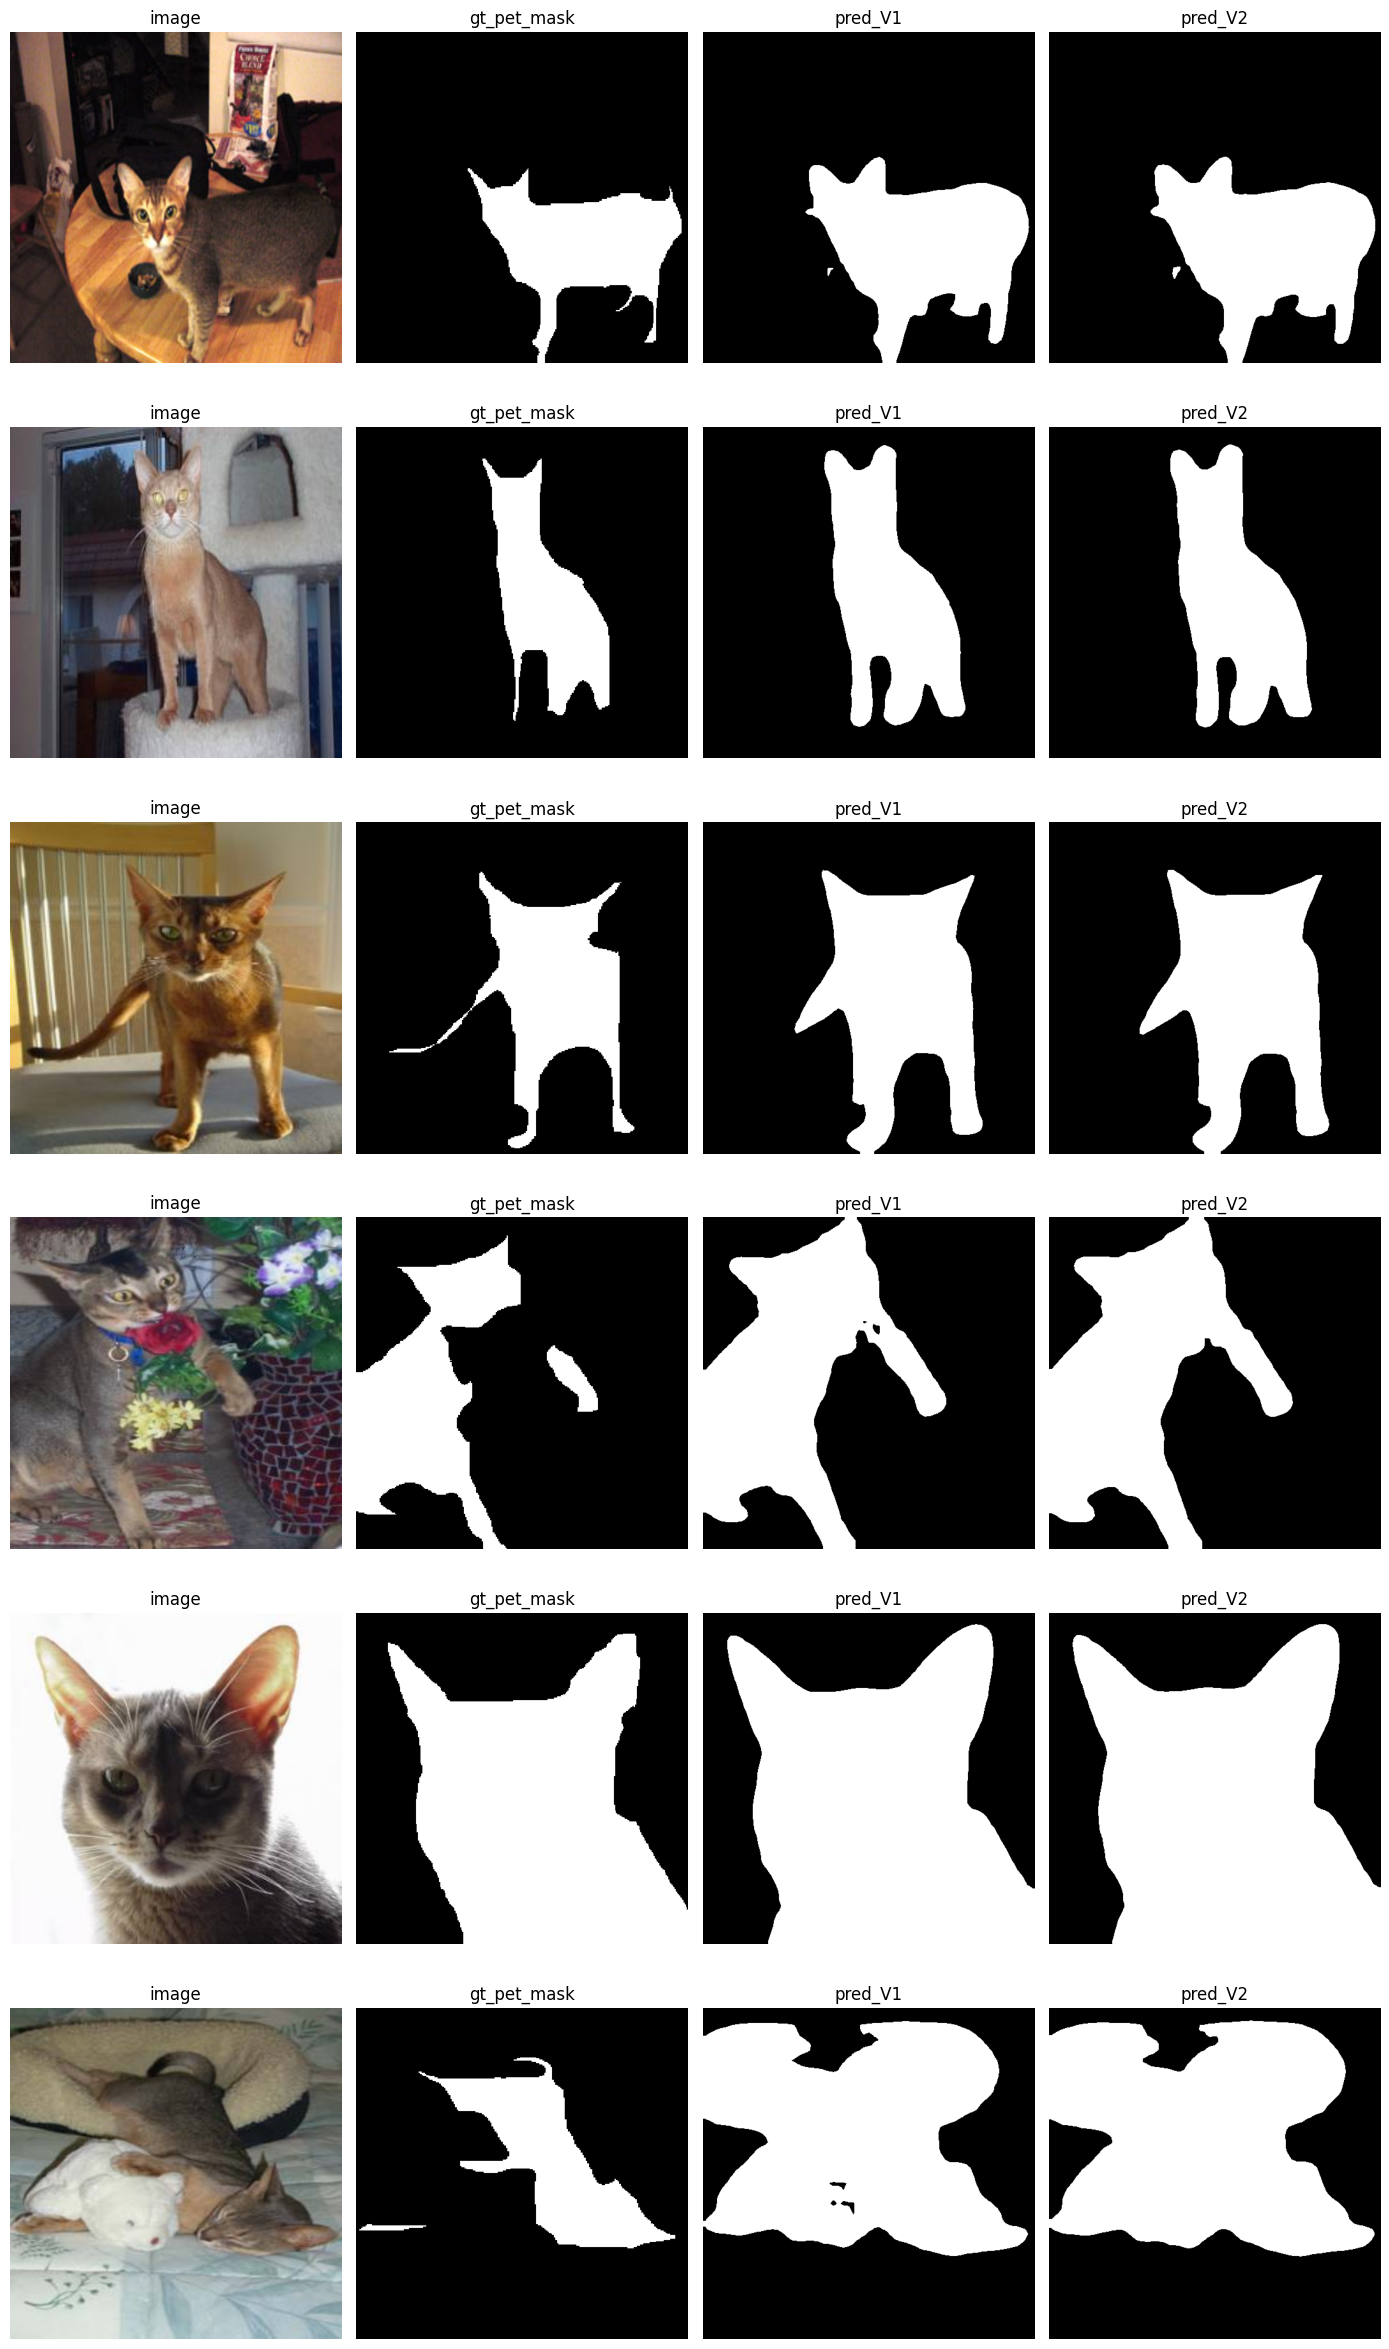

Saved: artifacts/figures/segmentation_metrics.png


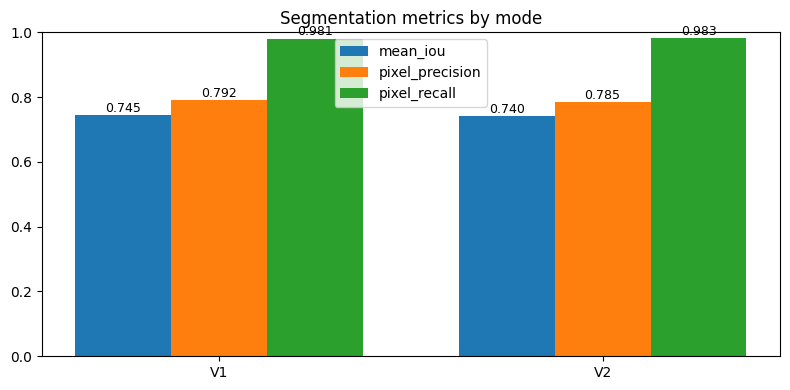

In [ ]:
# segmentation_examples.png
n_vis = len(seg_vis_samples)
fig, axes = plt.subplots(n_vis, 4, figsize=(14, 4 * n_vis))

if n_vis == 1:
    axes = np.expand_dims(axes, axis=0)

for r, sample in enumerate(seg_vis_samples):
    axes[r, 0].imshow(sample["image"].permute(1, 2, 0).numpy())
    axes[r, 0].set_title("image")
    axes[r, 0].axis("off")

    axes[r, 1].imshow(sample["gt"].numpy(), cmap="gray")
    axes[r, 1].set_title("gt_pet_mask")
    axes[r, 1].axis("off")

    axes[r, 2].imshow(sample["preds"]["V1"].numpy(), cmap="gray")
    axes[r, 2].set_title("pred_V1")
    axes[r, 2].axis("off")

    axes[r, 3].imshow(sample["preds"]["V2"].numpy(), cmap="gray")
    axes[r, 3].set_title("pred_V2")
    axes[r, 3].axis("off")

fig.tight_layout()
save_fig(fig, SEG_EXAMPLES_REL)
plt.show()

# segmentation_metrics.png
metrics_plot_df = pd.DataFrame([
    {
        "mode": mode_name,
        "mean_iou": metrics["mean_iou"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
    }
    for mode_name, metrics in seg_results.items()
]).sort_values("mode")

x = np.arange(len(metrics_plot_df))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width, metrics_plot_df["mean_iou"], width=width, label="mean_iou")
ax.bar(x, metrics_plot_df["precision"], width=width, label="pixel_precision")
ax.bar(x + width, metrics_plot_df["recall"], width=width, label="pixel_recall")

ax.set_xticks(x)
ax.set_xticklabels(metrics_plot_df["mode"])
ax.set_ylim(0, 1.0)
ax.set_title("Segmentation metrics by mode")
ax.legend()

for idx, row in metrics_plot_df.iterrows():
    ax.text(idx - width, row["mean_iou"] + 0.01, f"{row['mean_iou']:.3f}", ha="center", fontsize=9)
    ax.text(idx, row["precision"] + 0.01, f"{row['precision']:.3f}", ha="center", fontsize=9)
    ax.text(idx + width, row["recall"] + 0.01, f"{row['recall']:.3f}", ha="center", fontsize=9)

fig.tight_layout()
save_fig(fig, SEG_METRICS_REL)
plt.show()

In [ ]:
for mode_name, metrics in seg_results.items():
    row = {
        "experiment_id": mode_name,
        "task": "segmentation",
        "dataset": CONFIG["segmentation"]["dataset_name"],
        "seed": CONFIG["seed"],
        "model_summary": "DeepLabV3_ResNet50(weights=DEFAULT, cat/dog -> pet foreground)",
        "optimizer": np.nan,
        "lr": np.nan,
        "epochs_trained": 0,
        "best_val_accuracy": np.nan,
        "test_accuracy": np.nan,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "mean_iou": metrics["mean_iou"],
        "notes": metrics["notes"],
    }
    upsert_run_row(NB_DIR / RUNS_CSV_REL, row)

all_runs_df = read_runs(NB_DIR / RUNS_CSV_REL)
display(all_runs_df.sort_values("experiment_id").reset_index(drop=True))

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,Flowers102,42,"simple_cnn(trainable=346694, total=346694, fre...",AdamW,0.003,12,0.161765,NaN,NaN,NaN,NaN,simple-cnn-base
1,C2,classification,Flowers102,42,"simple_cnn(trainable=346694, total=346694, fre...",AdamW,0.003,12,0.171569,NaN,NaN,NaN,NaN,simple-cnn-aug
2,C3,classification,Flowers102,42,"resnet18(trainable=52326, total=11228838, free...",AdamW,0.002,6,0.788235,NaN,NaN,NaN,NaN,resnet18-head-only
3,C4,classification,Flowers102,42,"resnet18(trainable=8446054, total=11228838, fr...","AdamW(param_groups: layer4 lower LR, fc base LR)",0.001,8,0.911765,0.888925,NaN,NaN,NaN,resnet18-finetune-layer4+fc
4,V1,segmentation,OxfordIIITPet,42,"DeepLabV3_ResNet50(weights=DEFAULT, cat/dog ->...",NaN,NaN,0,NaN,NaN,0.791631,0.980761,0.745235,raw thresholding
5,V2,segmentation,OxfordIIITPet,42,"DeepLabV3_ResNet50(weights=DEFAULT, cat/dog ->...",NaN,NaN,0,NaN,NaN,0.785462,0.982717,0.740451,thresholding + morphology


In [ ]:
required_all_artifacts = [
    RUNS_CSV_REL,
    BEST_MODEL_REL,
    BEST_CONFIG_REL,
    BEST_CURVES_REL,
    CLASS_COMPARE_REL,
    AUG_PREVIEW_REL,
    SEG_EXAMPLES_REL,
    SEG_METRICS_REL,
]

print("Final artifact check:")
for rel_path in required_all_artifacts:
    exists = (NB_DIR / rel_path).exists()
    print(f"[{'OK' if exists else 'MISS'}] {rel_path}")

print("\nReport-ready relative paths:")
for rel_path in required_all_artifacts:
    print(rel_path)

Final artifact check:
[OK] artifacts/runs.csv
[OK] artifacts/best_classifier.pt
[OK] artifacts/best_classifier_config.json
[OK] artifacts/figures/classification_curves_best.png
[OK] artifacts/figures/classification_compare.png
[OK] artifacts/figures/augmentations_preview.png
[OK] artifacts/figures/segmentation_examples.png
[OK] artifacts/figures/segmentation_metrics.png

Report-ready relative paths:
artifacts/runs.csv
artifacts/best_classifier.pt
artifacts/best_classifier_config.json
artifacts/figures/classification_curves_best.png
artifacts/figures/classification_compare.png
artifacts/figures/augmentations_preview.png
artifacts/figures/segmentation_examples.png
artifacts/figures/segmentation_metrics.png


In [ ]:
final_runs = read_runs(NB_DIR / RUNS_CSV_REL).sort_values("experiment_id").reset_index(drop=True)

best_cls_row = final_runs[final_runs["task"] == "classification"].sort_values(
    "best_val_accuracy",
    ascending=False,
).iloc[0]

best_seg_row = final_runs[final_runs["task"] == "segmentation"].sort_values(
    "mean_iou",
    ascending=False,
).iloc[0]

print("Final summary")
print("-" * 80)
print(f"Best classification run: {best_cls_row['experiment_id']}")
print(f"  best_val_accuracy = {best_cls_row['best_val_accuracy']:.4f}")
print(f"  test_accuracy     = {best_cls_row['test_accuracy']:.4f}")
print()
print(f"Best segmentation run: {best_seg_row['experiment_id']}")
print(f"  precision = {best_seg_row['precision']:.4f}")
print(f"  recall    = {best_seg_row['recall']:.4f}")
print(f"  mean_iou  = {best_seg_row['mean_iou']:.4f}")

display(final_runs)

Final summary
--------------------------------------------------------------------------------
Best classification run: C4
  best_val_accuracy = 0.9118
  test_accuracy     = 0.8889

Best segmentation run: V1
  precision = 0.7916
  recall    = 0.9808
  mean_iou  = 0.7452


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,Flowers102,42,"simple_cnn(trainable=346694, total=346694, fre...",AdamW,0.003,12,0.161765,NaN,NaN,NaN,NaN,simple-cnn-base
1,C2,classification,Flowers102,42,"simple_cnn(trainable=346694, total=346694, fre...",AdamW,0.003,12,0.171569,NaN,NaN,NaN,NaN,simple-cnn-aug
2,C3,classification,Flowers102,42,"resnet18(trainable=52326, total=11228838, free...",AdamW,0.002,6,0.788235,NaN,NaN,NaN,NaN,resnet18-head-only
3,C4,classification,Flowers102,42,"resnet18(trainable=8446054, total=11228838, fr...","AdamW(param_groups: layer4 lower LR, fc base LR)",0.001,8,0.911765,0.888925,NaN,NaN,NaN,resnet18-finetune-layer4+fc
4,V1,segmentation,OxfordIIITPet,42,"DeepLabV3_ResNet50(weights=DEFAULT, cat/dog ->...",NaN,NaN,0,NaN,NaN,0.791631,0.980761,0.745235,raw thresholding
5,V2,segmentation,OxfordIIITPet,42,"DeepLabV3_ResNet50(weights=DEFAULT, cat/dog ->...",NaN,NaN,0,NaN,NaN,0.785462,0.982717,0.740451,thresholding + morphology
